# ML Models
Exécution des 3 modèles ML : BERTopic (topic modeling), NER (entités), Isolation Forest (anomalies).

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np

project_root = Path.cwd()
if not (project_root / 'data').exists():
    project_root = project_root.parent
sys.path.append(str(project_root))

data_path = project_root / 'data/processed/gdelt_benin_clean.csv'
df = pd.read_csv(data_path)
df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')
print(f'Loaded {len(df)} rows from {data_path.name}')
print(f'Date range: {df["date_parsed"].min()} → {df["date_parsed"].max()}')

Loaded 5089 rows from gdelt_benin_clean.csv
Date range: 2025-01-01 00:00:00 → 2026-05-02 00:00:00


## Model 1: BERTopic (Topic Modeling)
Identifie les thèmes médiatiques récurrents autour du Bénin.

In [2]:
from src.models.topic_model import extract_topics

benin_mask = (
    df.get('Actor1CountryCode', pd.Series(dtype=str)).astype(str).eq('BEN') |
    df.get('ActionGeo_FullName', pd.Series(dtype=str)).astype(str).str.contains('benin', case=False, na=False)
 )
raw_texts = df.loc[benin_mask, 'event_label'].astype(str).dropna()
benin_texts = [t.strip() for t in raw_texts if isinstance(t, str) and t.strip() and len(t.strip()) > 10]
if len(benin_texts) == 0:
    print('No Benin-related event_label texts found — skipping BERTopic.')
    topic_model = None
    topic_info = pd.DataFrame(columns=['Topic', 'Count'])
else:
    sample_size = min(300, len(benin_texts))
    sample_texts = np.random.choice(benin_texts, sample_size, replace=False).tolist()
    sample_texts = [s for s in sample_texts if s and len(s.strip()) > 5]
    if len(sample_texts) < 20:
        print(f'Too few samples ({len(sample_texts)}) — skipping BERTopic.')
        topic_model = None
        topic_info = pd.DataFrame(columns=['Topic', 'Count'])
    else:
        print(f'Training BERTopic on {len(sample_texts)} samples...')
        result = extract_topics(sample_texts, min_topic_size=15)

if 'result' in locals():
    topic_model = result.model
    topics_list = result.topics
    topic_info = topic_model.get_topic_info()
    print(f'\nTopics found: {len(topic_info)}')
    print('\nTop 5 topics by frequency:')
    print(topic_info.head(5)[['Topic', 'Count']].to_string(index=False))
else:
    topic_model = None
    topics_list = []
    topic_info = pd.DataFrame(columns=['Topic', 'Count'])

Training BERTopic on 300 samples...


/home/appolinaire/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading weights:   0%|                                                                            | 0/199 [00:00<?, ?it/s]


Loading weights: 100%|████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 4239.73it/s]


Topics found: 6

Top 5 topics by frequency:
 Topic  Count
     0    100
     1     50
     2     49
     3     48
     4     34


In [3]:
print('\nTopic Keywords:')
for topic_id in topic_info['Topic'].head(5):
    if topic_id == -1:
        print(f'Topic {topic_id}: [Outliers]')
        continue
    keywords = topic_model.get_topic(topic_id)
    kw_str = ', '.join([kw for kw, _ in keywords[:8]])
    print(f'Topic {topic_id}: {kw_str}')


Topic Keywords:
Topic 0: consultation, , , , , , , 
Topic 1: demande, aide, appel, accord, assistance, coopération, , 
Topic 2: publique, déclaration, protestation, , , , , 
Topic 3: coopération, matérielle, désapprobation, rejet, refus, non, militaire, force
Topic 4: diplomatique, engagement, , , , , , 


## Model 2: NER (Named Entity Recognition)
Extrait les entités nommées : personnes, organisations, lieux.

In [4]:
from src.models.ner_model import extract_entities
from collections import Counter
import re

# Prepare text for NER
df['ner_text'] = (
    df['Actor1Name'].fillna('').astype(str) + ' ' +
    df['Actor2Name'].fillna('').astype(str) + ' ' +
    df['ActionGeo_FullName'].fillna('').astype(str)
).str.strip()

print('Extracting entities...')
entities = extract_entities(df['ner_text'].tolist())

# Aggregate
person_counter = Counter()
org_counter = Counter()
location_counter = Counter()

NOISE_TOKENS = {'INCONNU', 'UNKNOWN', 'NA', 'N/A', 'NONE', 'NULL'}
COUNTRY_NOISE = {'BENIN', 'BEN', 'BENINESE'}

def clean_entity(val, kind):
    text = re.sub(r'\s+', ' ', str(val or '')).strip()
    if not text:
        return ''
    parts = [p.strip() for p in re.split(r'[\s,;/|]+', text) if p.strip()]
    cleaned = []
    for p in parts:
        upper_p = p.upper()
        if upper_p in NOISE_TOKENS:
            continue
        if kind in ('persons', 'orgs') and upper_p in COUNTRY_NOISE:
            continue
        cleaned.append(p.title() if p.isupper() else p)
    result = ' '.join(cleaned).strip()
    return result if len(result) >= 3 and not result.isdigit() else ''

for entity_dict in entities:
    for v in entity_dict.get('persons', []):
        clean_v = clean_entity(v, 'persons')
        if clean_v:
            person_counter[clean_v] += 1
    for v in entity_dict.get('orgs', []):
        clean_v = clean_entity(v, 'orgs')
        if clean_v:
            org_counter[clean_v] += 1
    for v in entity_dict.get('locations', []):
        clean_v = clean_entity(v, 'locations')
        if clean_v:
            location_counter[clean_v] += 1

print(f'\nExtracted {len(person_counter)} persons, {len(org_counter)} orgs, {len(location_counter)} locations')
print('\nTop 10 Persons:')
for person, count in person_counter.most_common(10):
    print(f'  {person}: {count}')
print('\nTop 10 Organizations:')
for org, count in org_counter.most_common(10):
    print(f'  {org}: {count}')
print('\nTop 10 Locations:')
for loc, count in location_counter.most_common(10):
    print(f'  {loc}: {count}')

Extracting entities...



Extracted 237 persons, 608 orgs, 31 locations

Top 10 Persons:
  Atlantique: 121
  Zou: 91
  Qué: 48
  Cotonou: 37
  Porto-Novo: 33
  Ouidah: 31
  Abomey: 30
  Africa: 24
  Alibori: 21
  Kandi: 20

Top 10 Organizations:
  Alibori: 148
  Africa: 89
  Niger: 66
  Nigeria: 36
  Ouidah: 29
  Minist: 27
  British: 26
  United Kingdom: 25
  Community: 24
  Business: 20

Top 10 Locations:
  Benin: 218
  Borgou: 55
  France: 32
  Egypt: 23
  Donga: 20
  Atakora: 13
  West African States: 10
  Parakou: 8
  Kouffo: 8
  Haiti: 7


## Model 3: Isolation Forest (Anomaly Detection)
Détecte les mois avec patterns anormaux (pics de volume, sentiment ou activité géopolitique).

In [2]:
from src.models.anomaly import detect_monthly_anomalies

monthly_result = detect_monthly_anomalies(df)
monthly = monthly_result.dataframe.copy()

print(f"Monthly aggregated data: {len(monthly)} months")
print("\nMonthly stats:")
print(
    monthly[
        [
            "year_month",
            "rows",
            "avg_tone",
            "goldstein_scale",
            "num_articles",
            "is_partial_month",
        ]
    ]
    .head(10)
    .to_string(index=False)
 )

Monthly aggregated data: 15 months

Monthly stats:
year_month  rows  avg_tone  goldstein_scale  num_articles  is_partial_month
   2025-01   705 -1.106617         0.580426          4966             False
   2025-02   293 -1.380411         0.869625          2239             False
   2025-03   322 -1.162040         0.808075          2453             False
   2025-04   171 -0.121355         1.680117          1186             False
   2025-05   219 -0.570265         1.433333          1648             False
   2025-06    75 -0.419531         1.332000           528             False
   2025-07    25 -0.575261         1.392000           166             False
   2025-10    57 -0.656073         1.138596           381             False
   2025-11    73 -0.881445        -0.041096           581             False
   2025-12   173 -2.773172        -0.758382          1364             False


In [3]:
print("Running anomaly detection service...")
print(f"Method used: {monthly_result.method}")

anomalies = monthly[monthly["is_anomaly"]]
partial_signals = monthly[monthly["is_partial_signal"]]

print(f"\nAnomalous months: {len(anomalies)}")
if not anomalies.empty:
    print(
        anomalies[
            ["year_month", "rows", "anomaly_score", "is_partial_month"]
        ]
        .sort_values("anomaly_score", ascending=False)
        .to_string(index=False)
    )

print(f"\nPartial-month signals: {len(partial_signals)}")
if not partial_signals.empty:
    print(
        partial_signals[
            ["year_month", "rows", "observed_days", "expected_days"]
        ]
        .to_string(index=False)
    )

Running anomaly detection service...
Method used: isolation_forest

Anomalous months: 1
year_month  rows  anomaly_score  is_partial_month
   2025-12   173       0.612221             False

Partial-month signals: 1
year_month  rows  observed_days  expected_days
   2026-05     8              2              2


In [4]:
print("\n=== Comparative Summary ===")
comparison = monthly[
    [
        "year_month",
        "rows",
        "avg_tone",
        "goldstein_scale",
        "num_articles",
        "anomaly_score",
        "is_anomaly",
        "is_partial_signal",
        "method",
    ]
].copy()
print(comparison.sort_values("anomaly_score", ascending=False).head(15).to_string(index=False))


=== Comparative Summary ===
year_month  rows  avg_tone  goldstein_scale  num_articles  anomaly_score  is_anomaly  is_partial_signal           method
   2025-12   173 -2.773172        -0.758382          1364       0.612221        True              False isolation_forest
   2026-05     8 -2.541334         0.187500            44       0.559576       False               True isolation_forest
   2026-02   791 -2.063033         0.147661          5200       0.544913       False              False isolation_forest
   2025-04   171 -0.121355         1.680117          1186       0.542822       False              False isolation_forest
   2026-01   817 -1.587441         0.789718          5654       0.534887       False              False isolation_forest
   2026-04   640 -1.758595         0.505312          4097       0.505661       False              False isolation_forest
   2025-11    73 -0.881445        -0.041096           581       0.498612       False              False isolation_forest
   

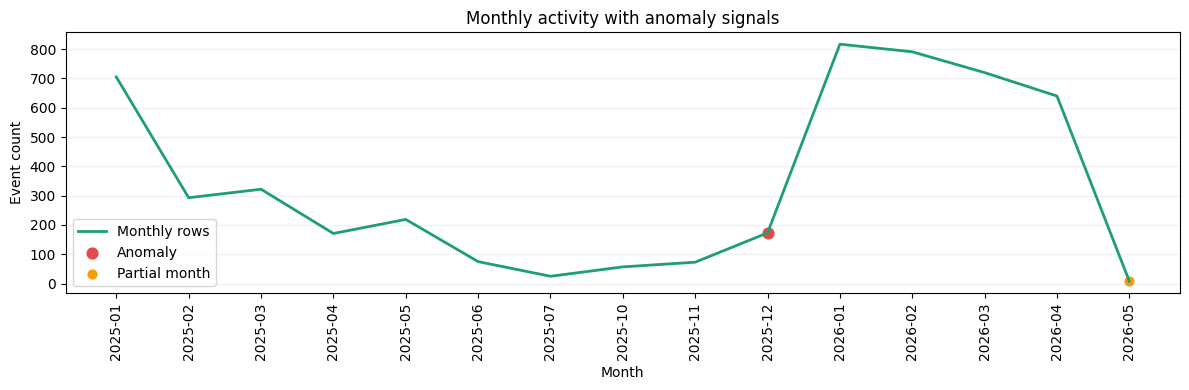

In [5]:
import matplotlib.pyplot as plt

if monthly.empty:
    print("No monthly data to plot.")
else:
    x = range(len(monthly))
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(x, monthly["rows"], color="#1D9E75", linewidth=2, label="Monthly rows")

    anomaly_idx = [i for i, v in enumerate(monthly["is_anomaly"]) if bool(v)]
    partial_idx = [i for i, v in enumerate(monthly["is_partial_signal"]) if bool(v)]

    ax.scatter(
        anomaly_idx,
        monthly.iloc[anomaly_idx]["rows"],
        color="#E24B4A",
        s=60,
        label="Anomaly",
    )
    ax.scatter(
        partial_idx,
        monthly.iloc[partial_idx]["rows"],
        color="#F59E0B",
        s=40,
        label="Partial month",
    )

    ax.set_title("Monthly activity with anomaly signals")
    ax.set_xlabel("Month")
    ax.set_ylabel("Event count")
    ax.set_xticks(list(x))
    ax.set_xticklabels(monthly["year_month"], rotation=90)
    ax.legend()
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()

## Summary
- **BERTopic**: Extracts semantic topics from event labels (e.g., security, diplomacy, governance).
- **NER**: Identifies key persons, organizations, and locations from GDELT structured fields.
- **Isolation Forest**: Flags months with anomalous event patterns (volume, sentiment, conflict intensity).

## Model 4: Media Impact Predictor (Saved Model)
Charge le modele sauvegarde et verifie une prediction rapide sur un echantillon.

In [2]:
from pathlib import Path
import sys
from src.models.media import (
    build_feature_frame,
    build_media_label,
    load_media_domains,
    load_model,
    train_and_save_media_model,
)

project_root = Path.cwd()
if not (project_root / "data").exists():
    project_root = project_root.parent
sys.path.append(str(project_root))

model_path = project_root / "models" / "media_model" / "media_rf.pkl"
metrics_path = project_root / "models" / "media_model" / "media_metrics.json"
force_retrain = True

benin_domains, international_domains = load_media_domains()
df["media_label"] = build_media_label(
    dataframe=df,
    benin_domains=benin_domains,
    international_domains=international_domains,
)
training_df = df.dropna(subset=["media_label"]).copy()
features = [
    "EventRootCode",
    "EventBaseCode",
    "GoldsteinScale",
    "AvgTone",
    "ActionGeo_CountryCode",
    "Actor1CountryCode",
    "Actor2CountryCode",
    "mois",
    "sentiment",
]
X = build_feature_frame(training_df, feature_columns=features)
training_df = training_df.assign(**{c: X[c] for c in X.columns})

if force_retrain or not model_path.exists():
    artifacts = train_and_save_media_model(
        dataframe=training_df,
        features=features,
        target="media_label",
        output_dir=project_root / "models" / "media_model",
        model_type="random_forest",
        split_strategy="time",
    )
    print("Saved model:", artifacts.model_path)
    print("Saved metrics:", artifacts.metrics_path)

model = load_model(model_path)
sample_df = training_df[features].dropna().head(10).copy()
preds = model.predict(sample_df)
print("Sample predictions:", preds)
print("Metrics file:", metrics_path)

Saved model: /home/appolinaire/projects/benin-insights-challenge-team2/models/media_model/media_rf.pkl
Saved metrics: /home/appolinaire/projects/benin-insights-challenge-team2/models/media_model/media_metrics.json
Sample predictions: [1. 1. 1. 1. 0. 1. 1. 0. 1. 1.]
Metrics file: /home/appolinaire/projects/benin-insights-challenge-team2/models/media_model/media_metrics.json


## Model 4: Media Impact Predictor (Train + Save)
Entraine le modele, sauvegarde dans `models/media_model/`, puis affiche les metriques de base.

In [3]:
from pathlib import Path
import sys
from src.models.media import build_feature_frame, build_media_label, load_media_domains, train_and_save_media_model

project_root = Path.cwd()
if not (project_root / "data").exists():
    project_root = project_root.parent
sys.path.append(str(project_root))

benin_domains, international_domains = load_media_domains()
df["media_label"] = build_media_label(
    dataframe=df,
    benin_domains=benin_domains,
    international_domains=international_domains,
)
training_df = df.dropna(subset=["media_label"]).copy()

features = [
    "EventRootCode",
    "EventBaseCode",
    "GoldsteinScale",
    "AvgTone",
    "ActionGeo_CountryCode",
    "Actor1CountryCode",
    "Actor2CountryCode",
    "mois",
    "sentiment",
]
X = build_feature_frame(training_df, feature_columns=features)
training_df = training_df.assign(**{c: X[c] for c in X.columns})
output_dir = project_root / "models" / "media_model"

artifacts = train_and_save_media_model(
    dataframe=training_df,
    features=features,
    target="media_label",
    output_dir=output_dir,
    model_type="random_forest",
    split_strategy="time",
)
print("Saved model:", artifacts.model_path)
print("Saved metrics:", artifacts.metrics_path)

Saved model: /home/appolinaire/projects/benin-insights-challenge-team2/models/media_model/media_rf.pkl
Saved metrics: /home/appolinaire/projects/benin-insights-challenge-team2/models/media_model/media_metrics.json


In [ ]:
# Describe dataset used for media model
describe_cols = ["media_label", "EventRootCode", "EventBaseCode", "GoldsteinScale", "AvgTone", "mois", "sentiment"]
available_cols = [c for c in describe_cols if c in training_df.columns]
print("Describe (media training set):")
print(training_df[available_cols].describe(include="all").transpose())

In [4]:
from src.models.media import build_feature_frame, build_media_label, load_media_domains, train_media_model

benin_domains, international_domains = load_media_domains()
df["media_label"] = build_media_label(
    dataframe=df,
    benin_domains=benin_domains,
    international_domains=international_domains,
)
training_df = df.dropna(subset=["media_label"]).copy()

candidate_features = [
    ["EventRootCode", "EventBaseCode", "GoldsteinScale", "AvgTone"],
    ["EventRootCode", "EventBaseCode", "GoldsteinScale", "AvgTone", "mois"],
    ["EventRootCode", "EventBaseCode", "GoldsteinScale", "AvgTone", "mois", "sentiment"],
]

def pick_metrics(metrics: dict) -> dict:
    return {
        "accuracy": round(metrics.get("accuracy", 0.0), 3),
        "macro_f1": round(metrics.get("macro avg", {}).get("f1-score", 0.0), 3),
        "weighted_f1": round(metrics.get("weighted avg", {}).get("f1-score", 0.0), 3),
    }

scores = []
for features in candidate_features:
    try:
        X = build_feature_frame(training_df, feature_columns=features)
    except ValueError:
        continue
    training_ready = training_df.assign(**{c: X[c] for c in X.columns})
    for model_type in ("logistic", "random_forest"):
        result = train_media_model(
            dataframe=training_ready,
            features=features,
            target="media_label",
            model_type=model_type,
            split_strategy="time",
        )
        scores.append({
            "model": model_type,
            "features": ", ".join(features),
            **pick_metrics(result.metrics),
        })

if scores:
    scores_df = pd.DataFrame(scores).sort_values(["macro_f1", "accuracy"], ascending=False)
    print(scores_df.to_string(index=False))
else:
    print("No candidate feature set available for evaluation.")

        model                                                               features  accuracy  macro_f1  weighted_f1
random_forest            EventRootCode, EventBaseCode, GoldsteinScale, AvgTone, mois     0.799     0.524        0.801
random_forest                  EventRootCode, EventBaseCode, GoldsteinScale, AvgTone     0.786     0.523        0.794
random_forest EventRootCode, EventBaseCode, GoldsteinScale, AvgTone, mois, sentiment     0.786     0.503        0.790
     logistic            EventRootCode, EventBaseCode, GoldsteinScale, AvgTone, mois     0.605     0.486        0.676
     logistic EventRootCode, EventBaseCode, GoldsteinScale, AvgTone, mois, sentiment     0.568     0.444        0.645
     logistic                  EventRootCode, EventBaseCode, GoldsteinScale, AvgTone     0.515     0.433        0.598


In [10]:
# Best baseline score summary
if "scores_df" in locals() and not scores_df.empty:
    best = scores_df.iloc[0].to_dict()
    print("Best model:", best.get("model"))
    print("Best features:", best.get("features"))
    print("Accuracy:", best.get("accuracy"))
    print("Macro F1:", best.get("macro_f1"))
    print("Weighted F1:", best.get("weighted_f1"))
else:
    print("scores_df not available. Run the baseline evaluation first.")

Best model: random_forest
Best features: EventRootCode, EventBaseCode, GoldsteinScale, AvgTone, mois
Accuracy: 0.799
Macro F1: 0.524
Weighted F1: 0.801


In [7]:
# Learning curves (time split, balanced accuracy)
from sklearn.model_selection import learning_curve
from sklearn.metrics import balanced_accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier

feature_set = ["EventRootCode", "EventBaseCode", "GoldsteinScale", "AvgTone", "mois"]
X = build_feature_frame(training_df, feature_columns=feature_set)
y = training_df["media_label"].astype(int)

categorical_features = [c for c in feature_set if X[c].dtype == object or X[c].dtype.name == "category"]
numeric_features = [c for c in feature_set if c not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_features),
        ("numeric", "passthrough", numeric_features),
    ]
)
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(n_estimators=200, random_state=42)),
    ]
)

# Use a simple shuffled split for curve visualization
train_sizes, train_scores, test_scores = learning_curve(
    model,
    X,
    y,
    scoring="balanced_accuracy",
    train_sizes=[0.2, 0.4, 0.6, 0.8, 1.0],
    cv=3,
    shuffle=True,
    random_state=42,
)
print("Learning curve (balanced accuracy)")
for size, tr, te in zip(train_sizes, train_scores, test_scores):
    print(f"{size}: train={tr.mean():.3f}±{tr.std():.3f}, test={te.mean():.3f}±{te.std():.3f}")

Learning curve (balanced accuracy)
678: train=0.998±0.002, test=0.523±0.013
1356: train=0.998±0.002, test=0.518±0.011
2035: train=0.995±0.001, test=0.518±0.006
2713: train=0.996±0.001, test=0.518±0.012
3392: train=0.994±0.001, test=0.521±0.017


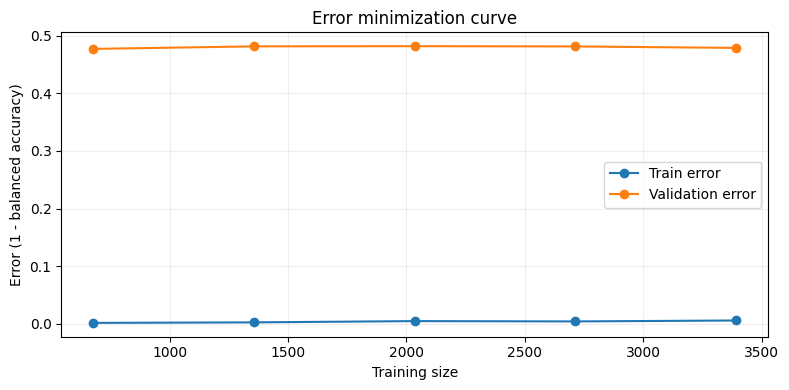

In [15]:
# Error minimization curve (1 - balanced accuracy)
import matplotlib.pyplot as plt

order = train_sizes.argsort()
sorted_sizes = train_sizes[order]
train_error = 1 - train_scores.mean(axis=1)[order]
test_error = 1 - test_scores.mean(axis=1)[order]

plt.figure(figsize=(8, 4))
plt.plot(sorted_sizes, train_error, marker="o", label="Train error")
plt.plot(sorted_sizes, test_error, marker="o", label="Validation error")
plt.title("Error minimization curve")
plt.xlabel("Training size")
plt.ylabel("Error (1 - balanced accuracy)")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:

benin_domains, international_domains = load_media_domains()
df["media_label"] = build_media_label(
    dataframe=df,
    benin_domains=benin_domains,
    international_domains=international_domains,
)
label_counts = df["media_label"].value_counts(dropna=False)
label_ratio = (label_counts / label_counts.sum()).round(3)
print("Label distribution (media_label):")
print(label_ratio)

baseline_accuracy = label_ratio.dropna().max() if not label_ratio.dropna().empty else 0
print("Baseline accuracy (majority class):", baseline_accuracy)

print("Missing values in features:")
print(df[features].isna().mean().round(3))

print("Unique EventRootCode values:", df["EventRootCode"].nunique())
print("Top EventRootCode counts:")
print(df["EventRootCode"].value_counts().head(10).to_string())

Label distribution (media_label):
media_label
1    0.857
0    0.143
Name: count, dtype: Float64
Baseline accuracy (majority class): 0.857
Missing values in features:
EventRootCode     0.0
EventBaseCode     0.0
GoldsteinScale    0.0
AvgTone           0.0
mois              0.0
sentiment         0.0
dtype: float64
Unique EventRootCode values: 19
Top EventRootCode counts:
EventRootCode
4     1358
1      713
5      611
2      340
11     325
19     297
17     218
8      187
3      178
7      175
